In [4]:
##Task 1 — Data Exploration with Pandas
# Import library
import pandas as pd

# -------------------------------
# Step 1 — Load Dataset
# -------------------------------
df = pd.read_csv("students.csv")
print("✅ Dataset loaded successfully\n")

# -------------------------------
# Step 2 — First 5 Rows
# -------------------------------
print("📌 First 5 Rows:\n")
print(df.head())

# -------------------------------
# Step 3 — Shape & Data Types
# -------------------------------
print("\n📌 Shape of Dataset (rows, columns):")
print(df.shape)

print("\n📌 Data Types:\n")
print(df.dtypes)

# -------------------------------
# Step 4 — Summary Statistics
# -------------------------------
print("\n📌 Summary Statistics:\n")
print(df.describe())

# -------------------------------
# Step 5 — Pass vs Fail Count
# -------------------------------
print("\n📌 Pass vs Fail Count:\n")
print(df['passed'].value_counts())

# -------------------------------
# Step 6 — Average Scores (Pass vs Fail)
# -------------------------------
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\n📌 Average Scores (Passed Students):\n")
print(pass_avg)

print("\n📌 Average Scores (Failed Students):\n")
print(fail_avg)

# -------------------------------
# Step 7 — Highest Average Student
# -------------------------------
df['average'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['average'].idxmax()]

print("\n📌 Top Performing Student:\n")
print(f"Name: {top_student['name']}")
print(f"Average Score: {top_student['average']:.2f}")

✅ Dataset loaded successfully

📌 First 5 Rows:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

📌 Shape of Dataset (rows, columns):
(15, 9)

📌 Data Types:

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: obje

In [5]:
##Task 2 — Data Visualization with Matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("students.csv")

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

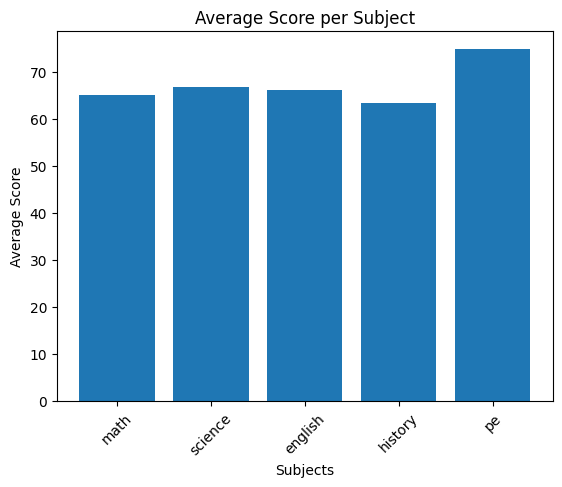

In [6]:
##1. Bar Chart — Average Score per Subject
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=45)

plt.savefig("plot1_bar.png")
plt.show()

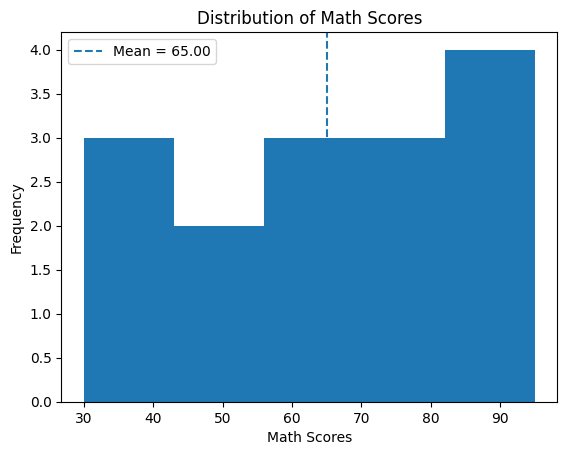

In [7]:
#2. Histogram — Math Score Distribution
math_scores = df['math']
mean_math = math_scores.mean()

plt.figure()
plt.hist(math_scores, bins=5)

plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

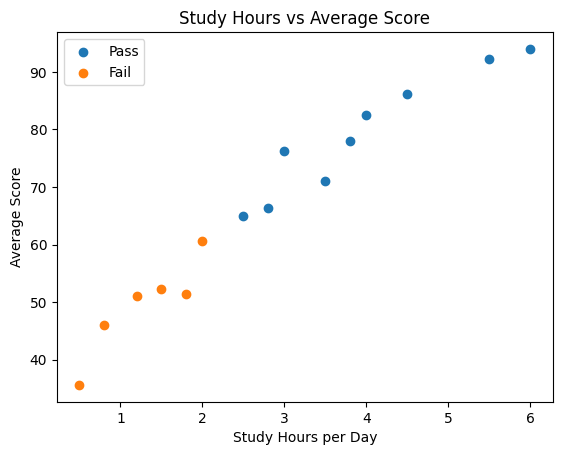

In [8]:
##3. Scatter Plot — Study Hours vs Avg Score
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure()

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

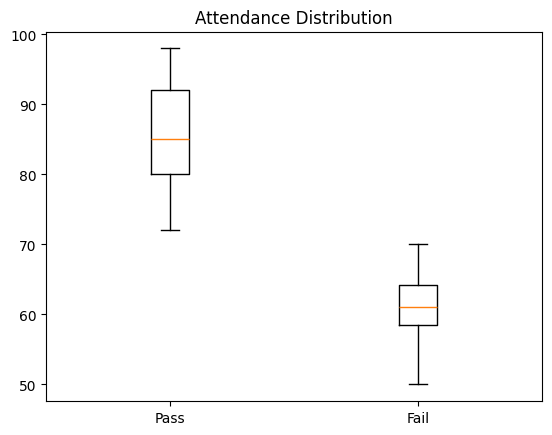

In [21]:
#4. Box Plot — Attendance (Pass vs Fail)
pass_att = df[df['passed']==1]['attendance_pct']
fail_att = df[df['passed']==0]['attendance_pct']

plt.figure()
plt.boxplot([pass_att, fail_att], tick_labels=['Pass','Fail'])
plt.title("Attendance Distribution")
plt.savefig("plot4_box.png")
plt.show()

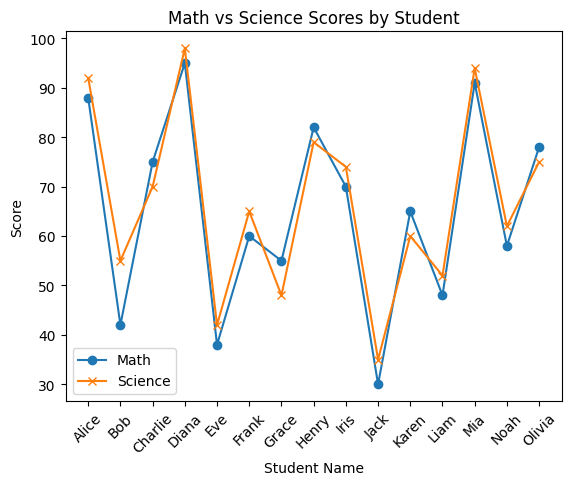

In [10]:
#5. Line Plot — Math vs Science Scores
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='x', label="Science")

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

In [11]:
##Task 3 — Seaborn Visualization Code
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("students.csv")

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

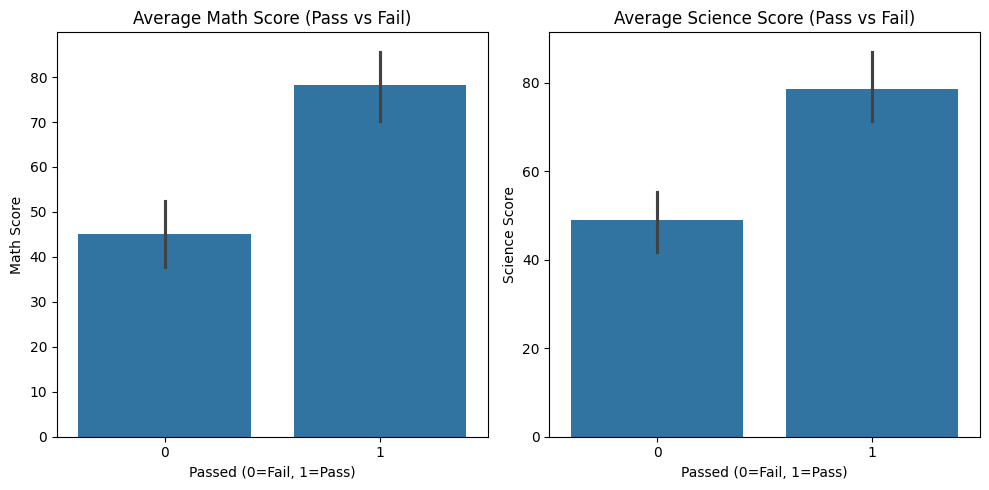

In [12]:
#1. Bar Plot — Math & Science (Pass vs Fail using subplot)
plt.figure(figsize=(10, 5))

# Subplot 1 — Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

# Subplot 2 — Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

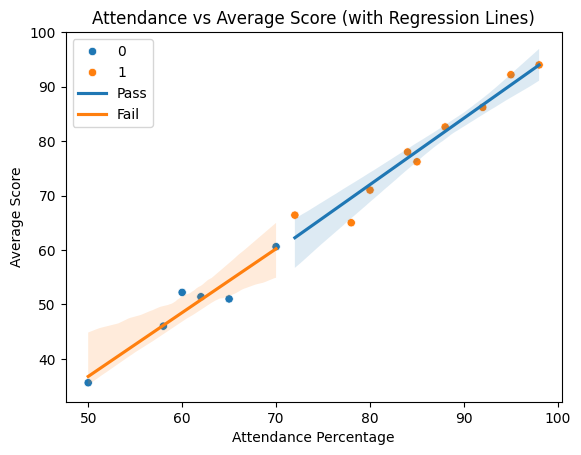

In [13]:
#2. Scatter + Regression — Attendance vs Avg Score
plt.figure()

# Scatter plot (colored by passed)
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression lines
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score (with Regression Lines)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [14]:
#3. Comparison Comment
# Seaborn vs Matplotlib:
# Working with Seaborn felt much more smooth and intuitive, especially when creating grouped plots

# and adding regression lines — it almost feels like it understands what you want to show.

# With Matplotlib, I had to put in more effort to adjust things manually, which gives more control,

# but also takes more time. Overall, Seaborn made the plots look cleaner and more presentable with less work.


In [15]:
##Task 4 — Machine Learning
#Step 1 — Prepare Data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("students.csv")

# Features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [16]:
#Step 2 — Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_acc = model.score(X_train_scaled, y_train)
print(f"\n📊 Training Accuracy: {train_acc:.2f}")


📊 Training Accuracy: 1.00


In [17]:
#Step 3 — Evaluate Model
# Predictions
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"📊 Test Accuracy: {test_acc:.2f}\n")

# Compare predictions
print("📌 Predictions vs Actual:\n")

test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {status}")

📊 Test Accuracy: 1.00

📌 Predictions vs Actual:

Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct


In [18]:
#Step 4 — Feature Importance:
import matplotlib.pyplot as plt
import numpy as np

coefficients = model.coef_[0]

# Pair with feature names
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance_sorted = sorted(feature_importance, key=lambda x: abs(x[1]), reverse=True)

print("\n📌 Feature Importance (sorted):\n")
for feature, coef in feature_importance_sorted:
    print(f"{feature}: {coef:.4f}")


📌 Feature Importance (sorted):

english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


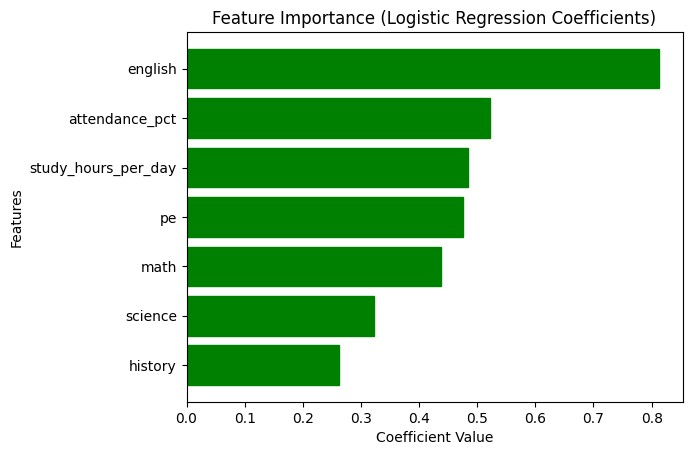

In [19]:
#Feature Importance Plot
features = [f[0] for f in feature_importance_sorted]
values = [f[1] for f in feature_importance_sorted]

# Colors: green (positive), red (negative)
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()
plt.barh(features, values)

# Apply colors manually (matplotlib restriction from your environment rules)
for i, bar in enumerate(plt.barh(features, values)):
    bar.set_color(colors[i])

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.gca().invert_yaxis()  # highest on top

plt.show()

In [20]:
#Step 5 — Predict New Student
import pandas as pd

new_student_df = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
)

# Scale
new_student_scaled = scaler.transform(new_student_df)

# Predict
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\n🎯 New Student Prediction:")
print(f"Prediction: {result}")
print(f"Probability (Fail, Pass): {probability}")


🎯 New Student Prediction:
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]
